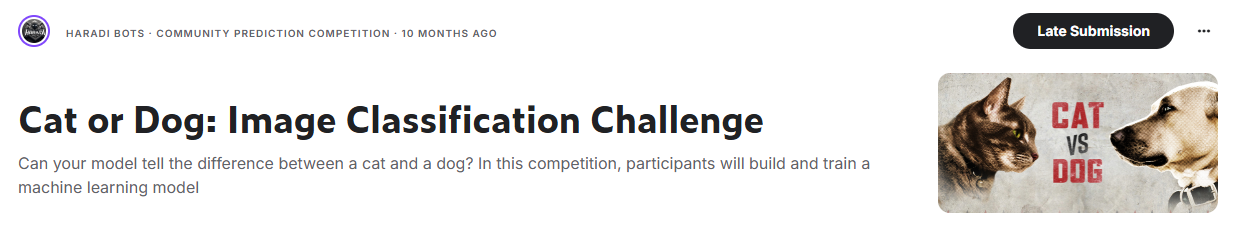

In [26]:
from sklearn import set_config
set_config(display="text")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split                   #문제/답 분리

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D    #-----CNN
from keras.layers import Dense, Flatten          #-----FC

from keras.applications import MobileNet, Xception          # --- 잘 알려진 모델
from keras.models import save_model, load_model             # --- 모델 저장&불러오기

# **🐾 Data Load**

In [2]:
my_base_path = "C:\\IT\\Datas\\#DL_catdog\\train"
train_dir = os.listdir(my_base_path)
train_dir

['cat', 'dog']

In [3]:
train_dir_cat = os.path.join(my_base_path, "cat")
train_dir_dog = os.path.join(my_base_path, "dog")
train_dir_cat, train_dir_dog

('C:\\IT\\Datas\\#DL_catdog\\train\\cat',
 'C:\\IT\\Datas\\#DL_catdog\\train\\dog')

In [4]:
#cat_img_list = os.listdir("C:\\IT\\Datas\\#DL_catdog\\train\\cat")
cat_img_list = os.listdir(train_dir_cat)
dog_img_list = os.listdir(train_dir_dog)
print( len(cat_img_list), cat_img_list[:10] )
print( len(dog_img_list), dog_img_list[:10] )

231 ['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.101.jpg', 'cat.102.jpg', 'cat.103.jpg', 'cat.104.jpg', 'cat.105.jpg', 'cat.106.jpg']
231 ['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.101.jpg', 'dog.102.jpg', 'dog.103.jpg', 'dog.104.jpg', 'dog.105.jpg', 'dog.106.jpg']


# **🐾 EDA**

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

sample_img = (cat_img_list[:10])

plt.figure(figsize=(10, 4))
for i, img_path in enumerate(sample_img):
  sp = plt.subplot(2, 5, i + 1)
  sp.axis('Off')
  img = mpimg.imread(train_dir_cat + "\\" + img_path)
  plt.imshow(img)
plt.show()

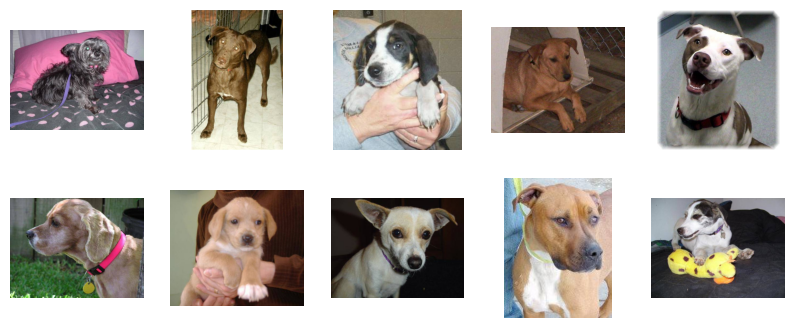

In [5]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

sample_img = (dog_img_list[:10])

plt.figure(figsize=(10, 4))
for i, img_path in enumerate(sample_img):
  sp = plt.subplot(2, 5, i + 1)
  sp.axis('Off')
  img = mpimg.imread(train_dir_dog + "\\" + img_path)
  plt.imshow(img)
plt.show()

> 사진크기 (240, 160)

# **🐾 전처리&가공**
* 스케일링

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
#ImageDataGenerator?

In [8]:
train_datagen = ImageDataGenerator( rescale = 1 /255.0 )
val_datagen = ImageDataGenerator( rescale = 1 /255.0 )
test_datagen = ImageDataGenerator( rescale = 1 /255.0 )

## flow_from_directory

<pre>
이런 구조로 되어있어야 사용 가능

"C:\\IT\\Datas\\#DL_catdog"
catdog
    train
        cat  ---- 0
        dog  ---- 1
    test  
        test ---- ?

In [9]:
train_path = "C:\\IT\\Datas\\#DL_catdog\\train"
val_path = "C:\\IT\\Datas\\#DL_catdog\\val"

train_gen = train_datagen.flow_from_directory(train_path, batch_size=20, class_mode = 'binary', target_size=(240, 160))
val_gen  = val_datagen.flow_from_directory(val_path, batch_size=20, class_mode = 'binary', target_size=(240, 160))

Found 462 images belonging to 2 classes.
Found 140 images belonging to 2 classes.


# **🐾 모델 생성&학습**

In [10]:
model = Sequential([
    Conv2D(filters=12, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu', input_shape=(240, 160, 3)),    # --------- RGB = 흑백은 1, 컬러는 3
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=20, kernel_size=(4, 4), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=512, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=['accuracy'])

C:\IT\python_workspace\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 236, 156, 12)        │             912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 118, 78, 12)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 114, 74, 16)         │           4,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 57, 37, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 54, 34, 20)          │           5,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 17, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9180)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,700,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,777,333 (18.22 MB)

 Trainable params: 4,777,333 (18.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#fit_res = model.fit( X_train, y_train, batch_size=256, epochs=40, validation_data=(X_test, y_test) )
fit_res = model.fit( train_gen, epochs=30, validation_data=val_gen )

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5346 - loss: 0.6965 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5173 - loss: 0.6772 - val_accuracy: 0.6143 - val_loss: 0.6731
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6667 - loss: 0.6442 - val_accuracy: 0.6500 - val_loss: 0.6591
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7294 - loss: 0.5788 - val_accuracy: 0.6071 - val_loss: 0.8429
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7251 - loss: 0.5410 - val_accuracy: 0.5929 - val_loss: 0.7278
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7100 - loss: 0.5412 - val_accuracy: 0.6357 - val_loss: 0.7354
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7814 - loss: 0.4327 - val_accuracy: 0.6643 - val_loss: 0.8211
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8723 - loss: 0.3167 - val_accuracy: 0.6643 - v

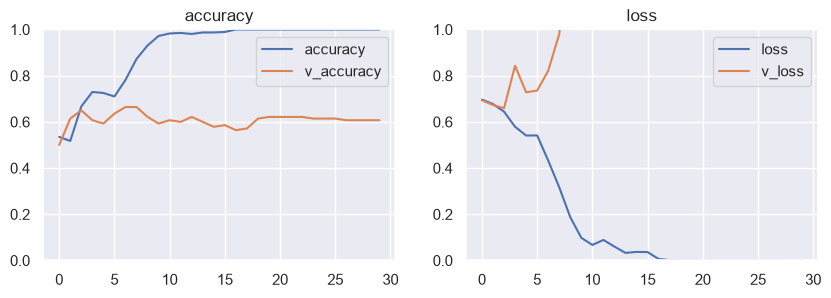

In [13]:
plt.figure(figsize=(10,3))
ax1 = plt.subplot(1,2,1)
ax1.plot(fit_res.history['accuracy'], label="accuracy")
ax1.plot(fit_res.history['val_accuracy'], label="v_accuracy")
ax1.legend()
ax1.set_ylim(0, 1)
ax1.set_title("accuracy")

ax2 = plt.subplot(1,2,2)
ax2.plot(fit_res.history['loss'], label="loss")
ax2.plot(fit_res.history['val_loss'], label="v_loss")
ax2.legend()
ax2.set_ylim(0, 1)
ax2.set_title("loss")

plt.show()

> 엄청난 오버피팅!!

# **🐾 모델 저장&불러오기**
* .save
* .load

In [14]:
model.save("./lec03_catdog_model.keras")

In [15]:
re_model = load_model("./lec03_catdog_model.keras")

In [16]:
re_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 236, 156, 12)        │             912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 118, 78, 12)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 114, 74, 16)         │           4,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 57, 37, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 54, 34, 20)          │           5,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 17, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9180)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,700,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,332,001 (54.67 MB)

 Trainable params: 4,777,333 (18.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,554,668 (36.45 MB)

# **🐾 예측**

In [17]:
test_path = "C:\\IT\\Datas\\#DL_catdog\\test"

test_gen = test_datagen.flow_from_directory(test_path, batch_size=20, class_mode=None, shuffle=False, target_size=(240, 160))

Found 50 images belonging to 1 classes.


In [18]:
pred_proba = model.predict(test_gen)
pred_proba[:10]   # ----------6.9690018e-04 = 0.000069690018 (0이 4개)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[9.0487403e-01],
       [2.8199598e-03],
       [1.8414262e-06],
       [9.0131650e-08],
       [9.9998403e-01],
       [1.0668135e-01],
       [9.1127753e-01],
       [9.9998128e-01],
       [1.8437956e-02],
       [1.0000000e+00]], dtype=float32)

In [19]:
test_gen.filenames[:3]

['test\\1.jpg', 'test\\10.jpg', 'test\\11.jpg']

dog test\1.jpg


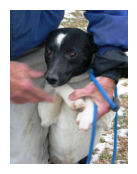

cat test\10.jpg


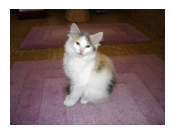

cat test\11.jpg


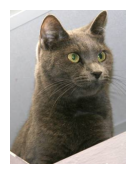

cat test\12.jpg


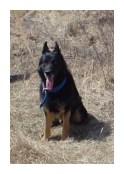

dog test\13.jpg


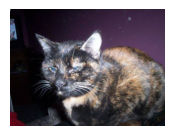

cat test\14.jpg


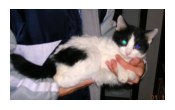

dog test\15.jpg


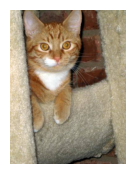

dog test\16.jpg


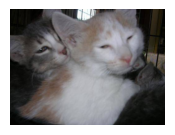

cat test\17.jpg


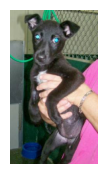

dog test\18.jpg


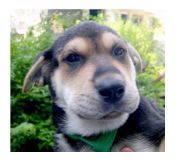

dog test\19.jpg


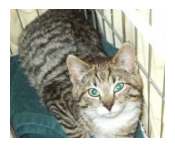

dog test\2.jpg


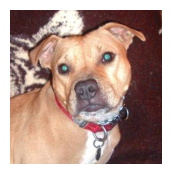

dog test\20.jpg


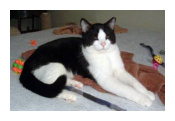

dog test\21.jpg


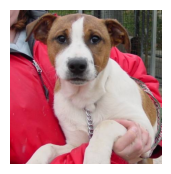

cat test\22.jpg


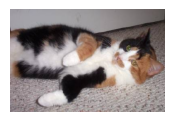

dog test\23.jpg


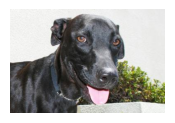

cat test\24.jpg


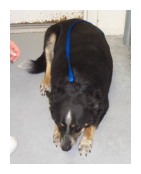

dog test\25.jpg


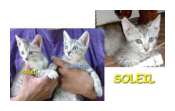

dog test\26.jpg


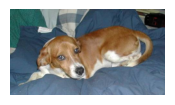

dog test\27.jpg


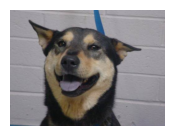

dog test\28.jpg


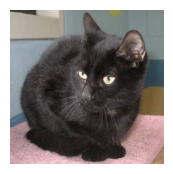

cat test\29.jpg


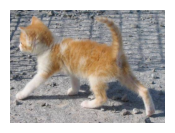

dog test\3.jpg


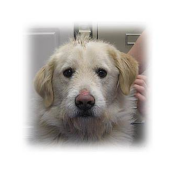

cat test\30.jpg


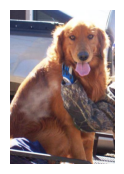

cat test\31.jpg


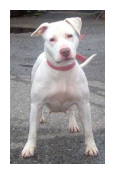

dog test\32.jpg


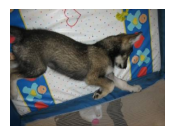

cat test\33.jpg


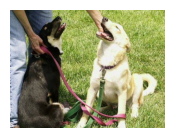

cat test\34.jpg


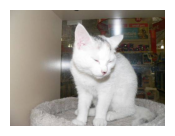

cat test\35.jpg


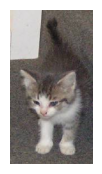

dog test\36.jpg


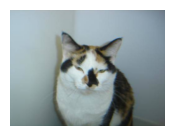

cat test\37.jpg


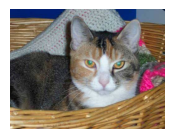

cat test\38.jpg


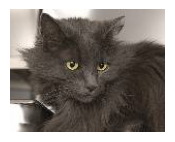

dog test\39.jpg


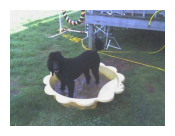

dog test\4.jpg


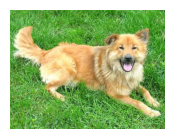

dog test\40.jpg


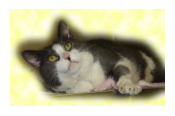

dog test\41.jpg


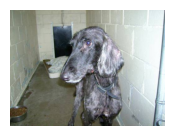

dog test\42.jpg


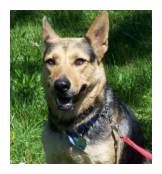

dog test\43.jpg


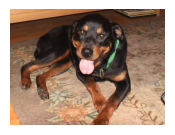

dog test\44.jpg


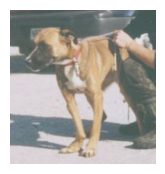

cat test\45.jpg


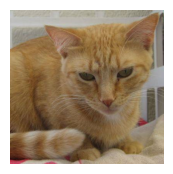

cat test\46.jpg


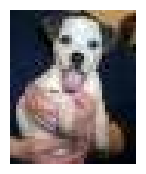

cat test\47.jpg


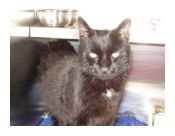

dog test\48.jpg


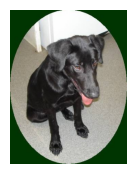

cat test\49.jpg


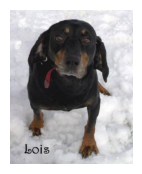

cat test\5.jpg


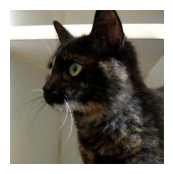

dog test\50.jpg


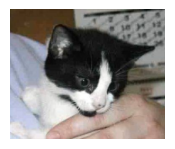

dog test\6.jpg


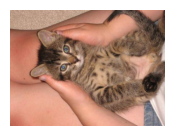

cat test\7.jpg


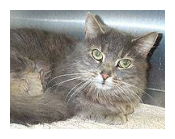

dog test\8.jpg


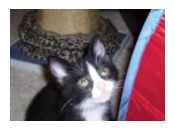

dog test\9.jpg


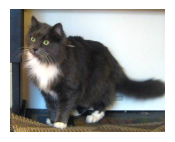

In [20]:
for i in range(len(pred_proba)) :
    if pred_proba[i] > 0.5 :
        print (f"dog {test_gen.filenames[i]}")
    else :
        print (f"cat {test_gen.filenames[i]}")

    plt.figure(figsize=(2, 2))
    img = mpimg.imread(test_path + "\\" + test_gen.filenames[i])
    plt.imshow(img)
    plt.axis('off')
    plt.grid(False)
    plt.show()

# **🐾 전이학습**
* 누군가 잘 만들어둔 모델로 교체
* https://keras.io/api/applications/

## MobileNet

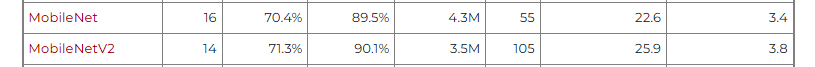

```python
keras.applications.MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name=None,
)

In [21]:
net_model = MobileNet(input_shape=(240, 160, 3), include_top=False, weights="imagenet")

C:\Users\Woori\AppData\Local\Temp\ipykernel_6464\1836394752.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  net_model = MobileNet(input_shape=(240, 160, 3), include_top=False, weights="imagenet")


In [22]:
net_model.trainable = False

In [23]:
model = Sequential([
    net_model,
    GlobalAveragePooling2D(),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

In [24]:
pred_proba = model.predict(test_gen)
pred_proba[:10]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step


array([[0.64509773],
       [0.46339974],
       [0.39552173],
       [0.18093993],
       [0.31024486],
       [0.4777403 ],
       [0.35175976],
       [0.57075655],
       [0.5442342 ],
       [0.4659648 ]], dtype=float32)

dog test\1.jpg


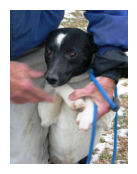

cat test\10.jpg


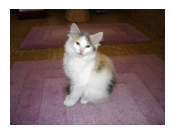

cat test\11.jpg


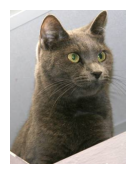

cat test\12.jpg


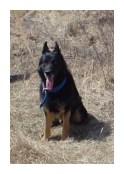

cat test\13.jpg


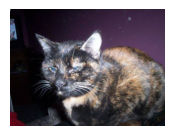

cat test\14.jpg


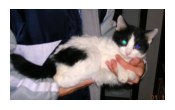

cat test\15.jpg


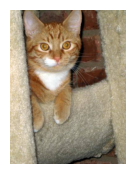

dog test\16.jpg


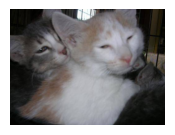

dog test\17.jpg


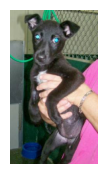

cat test\18.jpg


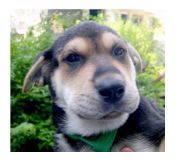

dog test\19.jpg


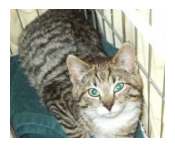

dog test\2.jpg


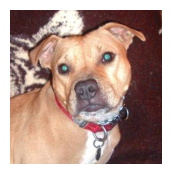

cat test\20.jpg


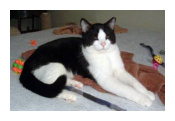

dog test\21.jpg


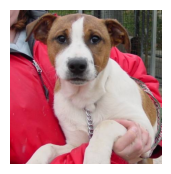

dog test\22.jpg


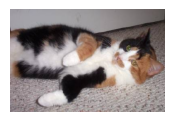

dog test\23.jpg


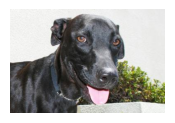

dog test\24.jpg


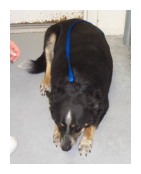

dog test\25.jpg


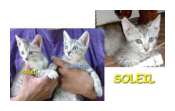

dog test\26.jpg


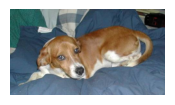

dog test\27.jpg


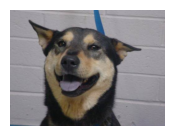

cat test\28.jpg


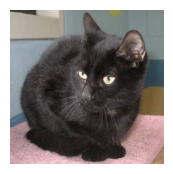

dog test\29.jpg


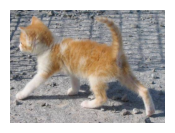

dog test\3.jpg


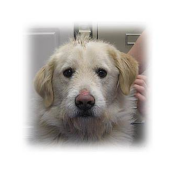

dog test\30.jpg


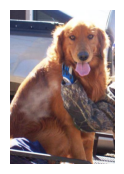

dog test\31.jpg


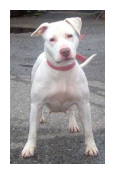

dog test\32.jpg


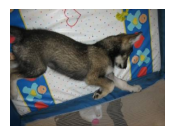

cat test\33.jpg


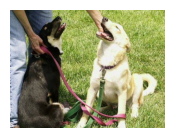

cat test\34.jpg


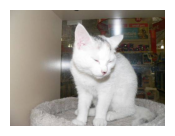

dog test\35.jpg


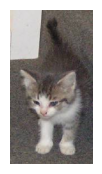

dog test\36.jpg


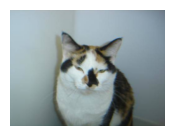

cat test\37.jpg


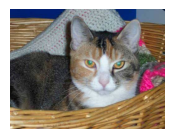

dog test\38.jpg


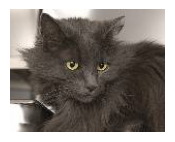

dog test\39.jpg


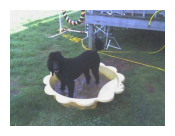

dog test\4.jpg


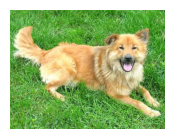

cat test\40.jpg


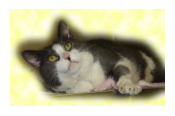

dog test\41.jpg


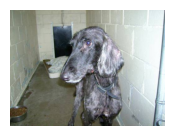

dog test\42.jpg


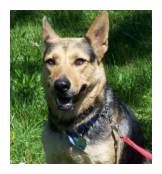

cat test\43.jpg


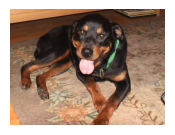

dog test\44.jpg


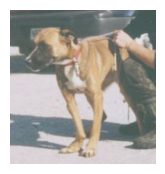

dog test\45.jpg


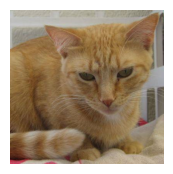

dog test\46.jpg


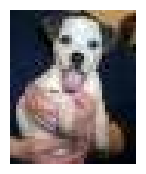

cat test\47.jpg


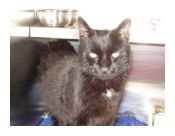

cat test\48.jpg


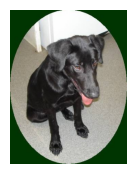

dog test\49.jpg


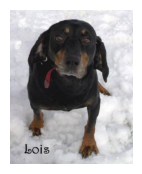

cat test\5.jpg


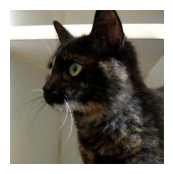

dog test\50.jpg


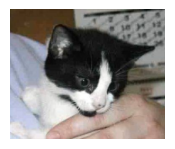

cat test\6.jpg


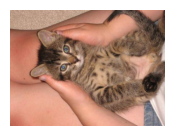

dog test\7.jpg


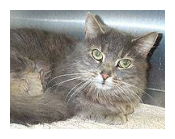

dog test\8.jpg


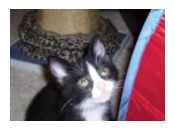

cat test\9.jpg


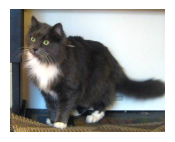

In [25]:
for i in range(len(pred_proba)) :
    if pred_proba[i] > 0.5 :
        print (f"dog {test_gen.filenames[i]}")
    else :
        print (f"cat {test_gen.filenames[i]}")

    plt.figure(figsize=(2, 2))
    img = mpimg.imread(test_path + "\\" + test_gen.filenames[i])
    plt.imshow(img)
    plt.axis('off')
    plt.grid(False)
    plt.show()

## Xception

In [27]:
Xcep_model = Xception(input_shape=(240, 160, 3), include_top=False, weights="imagenet")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [28]:
Xcep_model.trainable = False

In [29]:
model = Sequential([
    net_model,
    GlobalAveragePooling2D(),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

In [30]:
pred_proba = model.predict(test_gen)
pred_proba[:10]

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A9B0BA3C40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step


array([[0.5112822 ],
       [0.7677637 ],
       [0.6335906 ],
       [0.62453556],
       [0.67677104],
       [0.5013733 ],
       [0.69997084],
       [0.7876633 ],
       [0.6628796 ],
       [0.6694578 ]], dtype=float32)

dog test\1.jpg


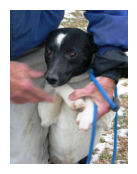

dog test\10.jpg


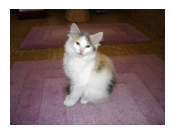

dog test\11.jpg


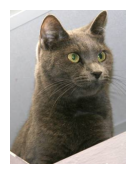

dog test\12.jpg


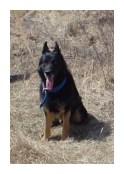

dog test\13.jpg


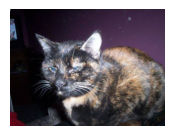

dog test\14.jpg


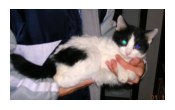

dog test\15.jpg


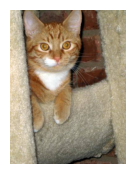

dog test\16.jpg


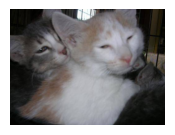

dog test\17.jpg


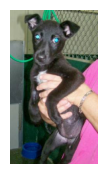

dog test\18.jpg


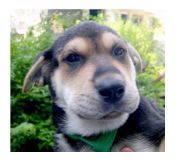

cat test\19.jpg


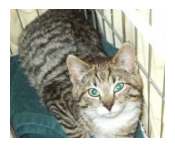

dog test\2.jpg


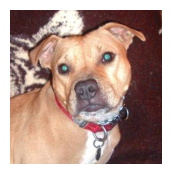

dog test\20.jpg


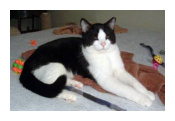

dog test\21.jpg


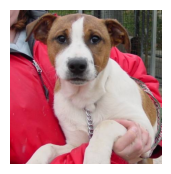

dog test\22.jpg


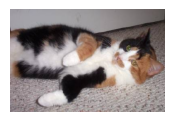

dog test\23.jpg


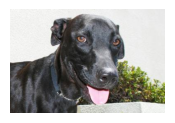

cat test\24.jpg


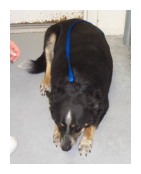

dog test\25.jpg


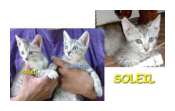

dog test\26.jpg


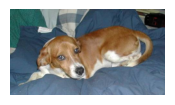

dog test\27.jpg


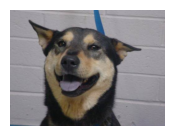

cat test\28.jpg


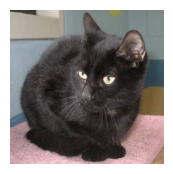

dog test\29.jpg


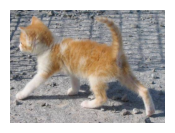

dog test\3.jpg


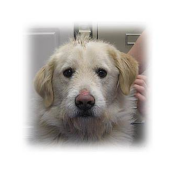

dog test\30.jpg


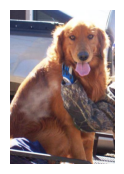

dog test\31.jpg


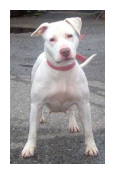

cat test\32.jpg


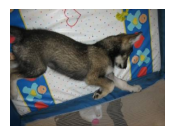

dog test\33.jpg


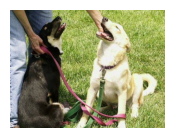

dog test\34.jpg


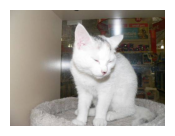

dog test\35.jpg


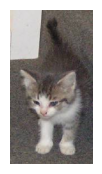

cat test\36.jpg


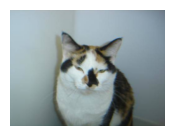

dog test\37.jpg


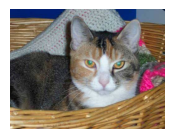

cat test\38.jpg


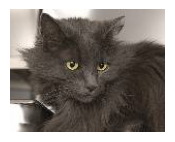

dog test\39.jpg


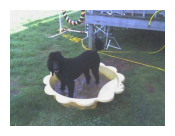

dog test\4.jpg


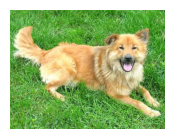

dog test\40.jpg


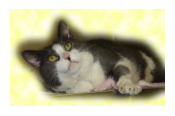

dog test\41.jpg


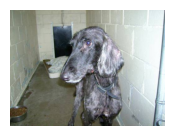

dog test\42.jpg


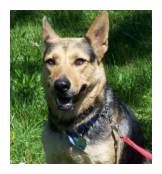

cat test\43.jpg


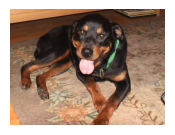

cat test\44.jpg


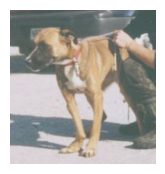

dog test\45.jpg


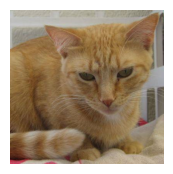

dog test\46.jpg


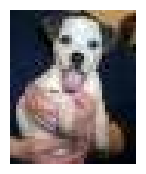

dog test\47.jpg


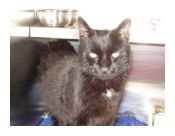

cat test\48.jpg


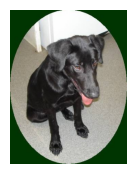

cat test\49.jpg


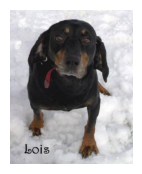

dog test\5.jpg


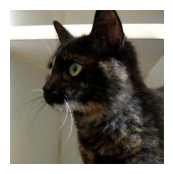

dog test\50.jpg


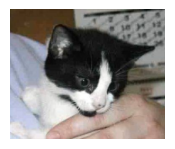

cat test\6.jpg


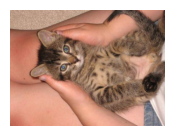

cat test\7.jpg


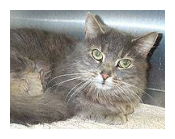

cat test\8.jpg


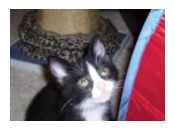

cat test\9.jpg


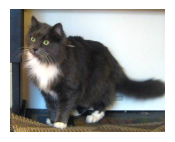

In [31]:
for i in range(len(pred_proba)) :
    if pred_proba[i] > 0.5 :
        print (f"dog {test_gen.filenames[i]}")
    else :
        print (f"cat {test_gen.filenames[i]}")

    plt.figure(figsize=(2, 2))
    img = mpimg.imread(test_path + "\\" + test_gen.filenames[i])
    plt.imshow(img)
    plt.axis('off')
    plt.grid(False)
    plt.show()